# Exploratory Data Analysis of Student Lifestyle

## Project Overview
This project explores relationship between lifestyle factors (social media use, sleep, physical activity) and the level of depressive symptoms in students using EDA

## Dataset
The dataset contains survey data from students, including:
- hours spent on social media
- sleep duration
- physical activity level
- depression score (CDPA)

Source: [](https://www.kaggle.com/datasets/aldinwhyudii/student-depression-and-lifestyle-100k-data)

## Research questions
- How is depression distributed among students?
- Is social media usage associated with higher depression scores?
- Does sleep duration relate to depression levels?
- Is physical activity linked to better mental health?

In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# - Pandas display settings -
# ---------------------------

# Show all columns in Dataframe output
pd.set_option("display.max_columns", None)

# Set maximum column width to display full content
pd.set_option("display.max_colwidth", None)

# Format formating point numbers
pd.set_option("display.float_format", "{:.2}".format)

# --------------------
# - Seaborn settings -
# --------------------

# Set overall seaborn theme
sns.set_theme(
  style="whitegrid", # white background with grid
  context="notebook" # font sizes optimited for Jupyter Notebook
)

# -------------------------------
# - Matplotlib default settings -
# -------------------------------

# Set default figure size
plt.rcParams["figure.figsize"] = (10, 6)

# Improve layout so labels don't overlap
plt.rcParams["figure.autolayout"] = True # automatic layout (автоматическое выравнивание)

# --------------------
# - Dataset cleaning -
# --------------------

# Read our dataset and put it in a "df" variable
df = pd.read_csv("../data/student_lifestyle_100k.csv")

# Display first five rows
df.head()

# Display eight random rows
df.sample(8)

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
2645,3646,22,Female,Engineering,2.1,6.7,3.7,1.9,96,5,False
8652,9653,18,Female,Medical,2.6,6.4,3.8,2.9,19,4,False
30624,31625,20,Female,Engineering,3.1,4.7,0.0,2.6,131,5,False
27102,28103,24,Male,Science,2.2,7.1,4.6,2.4,137,4,False
97182,98183,23,Male,Arts,2.4,7.7,2.5,3.2,130,2,False
2301,3302,21,Male,Arts,3.3,6.6,6.2,6.6,123,2,False
78111,79112,19,Female,Business,2.2,5.0,1.9,3.5,61,4,True
9808,10809,24,Male,Business,2.4,6.4,0.1,0.6,12,6,False


The dataset resembles questionnaire data collected during a student survey. It contains quantitative data on sleep time, study time, physical activity, and time spent on social media, a stress scale from 1 to 10, and a Boolean value indicating whether a given student is depressed.
There are no clear trends; some students spend very little time on social media, sleep little, engage in no physical activity, or study almost entirely.

In [17]:
# Show number of observations and features
df.shape

# Show all columns
df.columns

# Show dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


The dataset contains 100,000 observations and 11 features describing students' characteristics, lifestyle factors, and mental health indicators. The data includes numerical, categorical, and boolean variables, with numerical features predominating. No missing values were found in the dataset. All features have appropriate data types corresponding to their meaning, and no type conversions were required.

### Target variable and key factors

The target variable of this analysis is Depression, a boolean indicator of depressive symptoms.
The analysis focuses on the following lifestyle-related factors:

- Sleep_Duration
- Study_Hours
- Social_Media_Hours
- Physical_Activity

In [18]:
# Missing values amount and ratio dataframe
missing_summary = pd.DataFrame({
  "missing_count": df.isna().sum(),
  "missing_ratio": df.isna().mean()
})

# Sorting missing values dataframe
missing_summary = missing_summary.sort_values(
  by="missing_ratio",
  ascending=False
)

missing_summary

,missing_count,missing_ratio
Student_ID,0,0.0
Age,0,0.0
Gender,0,0.0
Department,0,0.0
CGPA,0,0.0
Sleep_Duration,0,0.0
Study_Hours,0,0.0
Social_Media_Hours,0,0.0
Physical_Activity,0,0.0
Stress_Level,0,0.0


### Misssing values analysis

No missing values were found in the dataset.
All features are fully populated, therefore no imputation
or row removal was required at this stage.

In [19]:
# Select all number value from dataset
numeric_df = df.select_dtypes(include=['number'])

# Find the maximum and minimum in each numerical column
values_analysis = pd.DataFrame({
  "max": numeric_df.max(),
  "min": numeric_df.min()
})

values_analysis

,max,min
Student_ID,1e+05,1e+03
Age,2.4e+01,1.8e+01
CGPA,4.0,1.6
Sleep_Duration,1.2e+01,3.0
Study_Hours,1.3e+01,0.0
Social_Media_Hours,1e+01,0.0
Physical_Activity,1.5e+02,0.0
Stress_Level,1e+01,2.0


### Value ranges and sanity checks

All numerical features fall within reasonable and logically
consistent ranges. No impossible or clearly erroneous values
were detected (e.g., negative ages or unrealistically high
sleep durations). Therefore, no additional data cleaning
was required at this stage.

### Data cleaning summary

The dataset does not contain missing values, and all features
have appropriate data types. A sanity check of numerical
variables showed that all values fall within logically possible
ranges. Some variables contain extreme but plausible values
(e.g., low sleep duration or zero study hours), which will be
further examined during the exploratory analysis.

In [20]:
#Display brief statistical summary of numerical features
df.describe()

# Count True/False values in Depression colums
depression_counts = df.Depression.value_counts()
depression_counts

# Find the difference between each boolean value
int(depression_counts.__getitem__(0))/int(depression_counts.__getitem__(1))

C:\TEMP\ipykernel_16076\3272484227.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  int(depression_counts.__getitem__(0))/int(depression_counts.__getitem__(1))


8.938382031405288

### Descriptive statistics

The numerical features exhibit relatively stable central tendencies, as the mean and median values are close or, in some cases, identical. This suggests that most distributions are fairly symmetric and not strongly skewed.

At the same time, a noticeable spread is observed between the interquartile ranges and the minimum/maximum values for several variables. In some cases, the distance between quartiles and extreme values exceeds a twofold difference, indicating the presence of extreme but potentially valid observations.

Most numerical features operate within relatively small ranges (generally between 0 and 12), reflecting daily or short-term behavioral measures. In contrast, *Age* and *Physical_Activity* span wider ranges (approximately 18–24 and 0–150, respectively), which is consistent with their different measurement scales.

### Target variable distribution

The target variable *Depression* shows a clear class imbalance. The number of students without depressive symptoms significantly exceeds the number of students classified as depressed, with the ratio being close to 9:1.

This imbalance provides important context for the analysis and should be taken into account when interpreting group comparisons and visualizations involving the target variable.

Text(0, 0.5, 'Count')

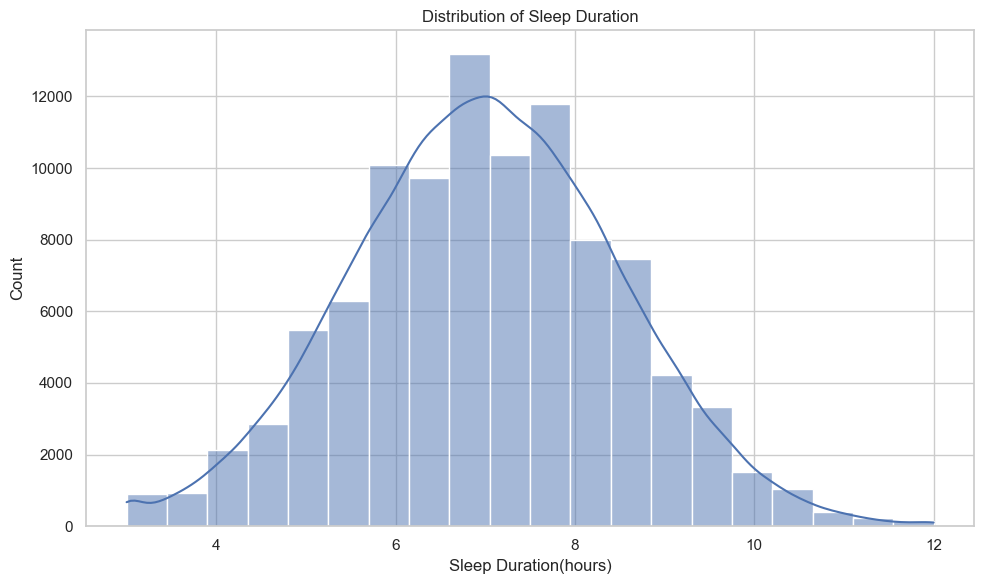

In [ ]:
# -----------------------
# - Univariate analysis -
# -----------------------

# Ploting histogramm
sns.histplot(
  data=df, # данные
  x="Sleep_Duration", # столбец
  bins=20, # кол-во "столбцов" в гистограмме
  kde=True # сглаженные линии
)

plt.title("Distribution of Sleep Duration")
plt.xlabel("Sleep Duration(hours)")
plt.ylabel("Count")

The distribution of sleep duration is approximately symmetric and centered around 6–8 hours, indicating that the majority of students follow a typical sleep pattern. The presence of a smooth, bell-shaped curve suggests a near-normal distribution with no strong skewness.

A small number of observations are located at both extremes, including shorter sleep durations below 4 hours and longer durations above 10 hours. However, these values are relatively rare and appear to represent plausible but less common sleep behaviors rather than data anomalies.

Text(0, 0.5, 'Count')

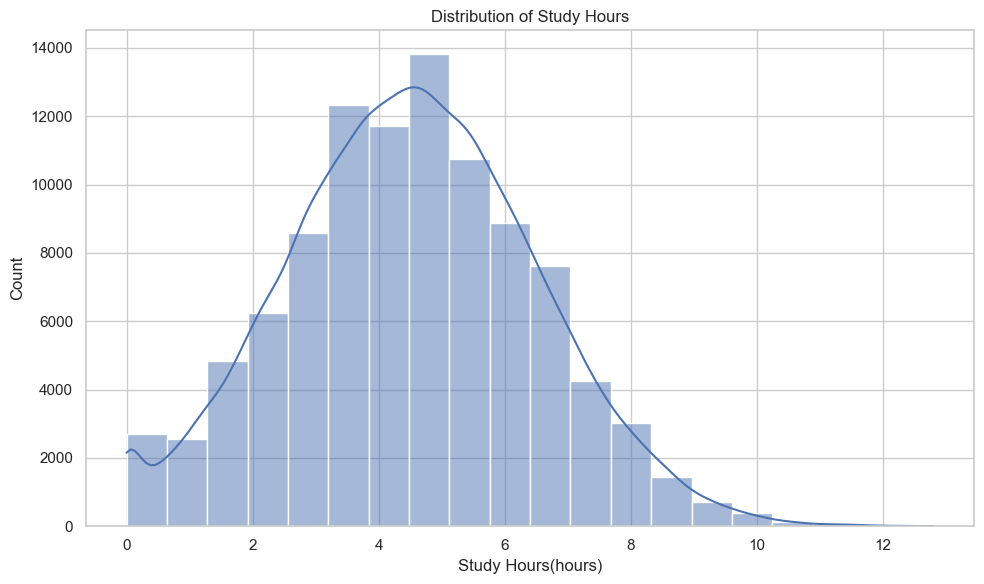

In [22]:
sns.histplot(
  data=df, # данные
  x="Study_Hours", # столбец
  bins=20, # кол-во "столбцов" в гистограмме
  kde=True # сглаженные линии
)

plt.title("Distribution of Study Hours")
plt.xlabel("Study Hours(hours)")
plt.ylabel("Count")

The distribution of study hours shows a slight left skew, although the deviation from symmetry is not pronounced. Most observations are concentrated in the range of approximately 3 to 5 hours per day, indicating a typical study duration for the majority of students.

Values around 1.5–2 hours and 6–7 hours occur less frequently, while very low study durations (below 1.5 hours) and high values (above 8 hours) are relatively rare. Students studying for extended periods of 10–12 hours per day are almost absent from the dataset, suggesting that such intensive study behavior is uncommon.

Text(0, 0.5, 'Count')

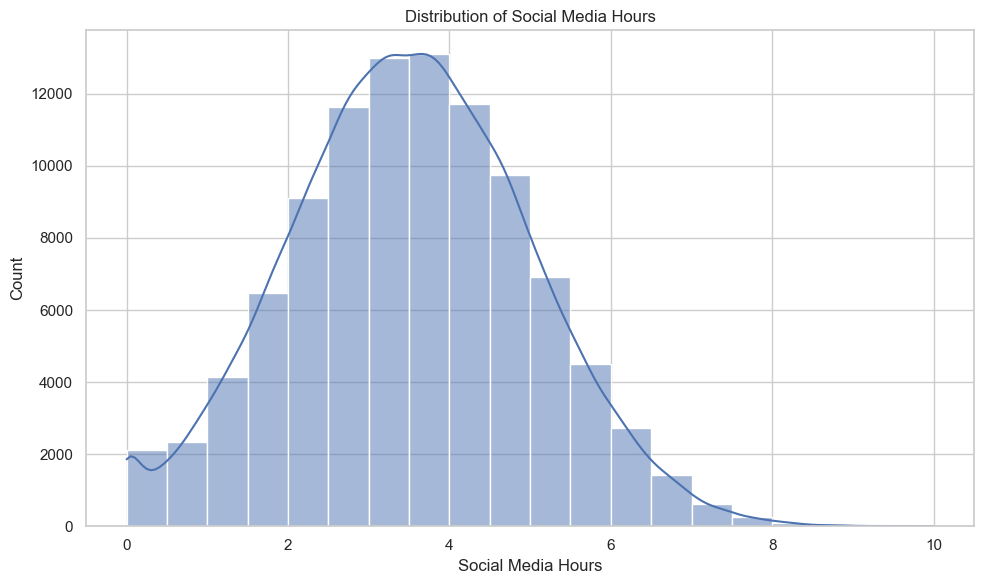

In [23]:
sns.histplot(
  data=df, # данные
  x="Social_Media_Hours", # столбец
  bins=20, # кол-во "столбцов" в гистограмме
  kde=True # сглаженные линии
)

plt.title("Distribution of Social Media Hours")
plt.xlabel("Social Media Hours")
plt.ylabel("Count")

The distribution of social media usage is relatively smooth and approximately symmetric, with the highest concentration of values observed in the range of 3 to 5 hours per day. This suggests that moderate social media use is typical for most students.

The distribution exhibits gradual declines toward both lower and higher extremes. While there are students who spend little to no time on social media, as well as those with relatively high daily usage, these cases are less frequent and form the tails of the distribution rather than representing anomalies.

Text(0, 0.5, 'Count')

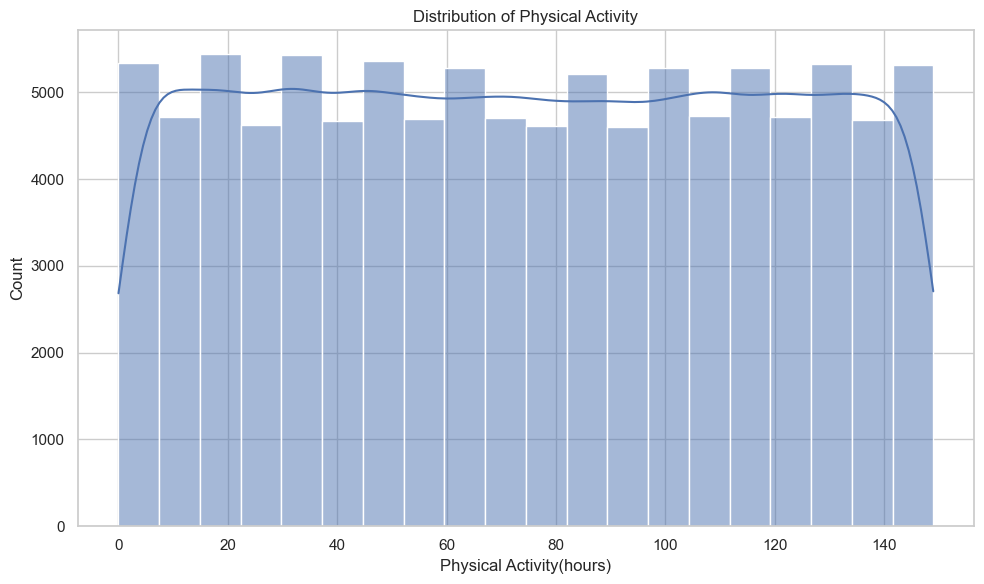

In [24]:
sns.histplot(
  data=df, # данные
  x="Physical_Activity", # столбец
  bins=20, # кол-во "столбцов" в гистограмме
  kde=True # сглаженные линии
)

plt.title("Distribution of Physical Activity")
plt.xlabel("Physical Activity(hours)")
plt.ylabel("Count")

Physical activity is distributed evenly across the entire range, without a distinct center, which distinguishes it from other behavioral traits and may indicate the specifics of the formation of this indicator.

Text(0, 0.5, 'Count')

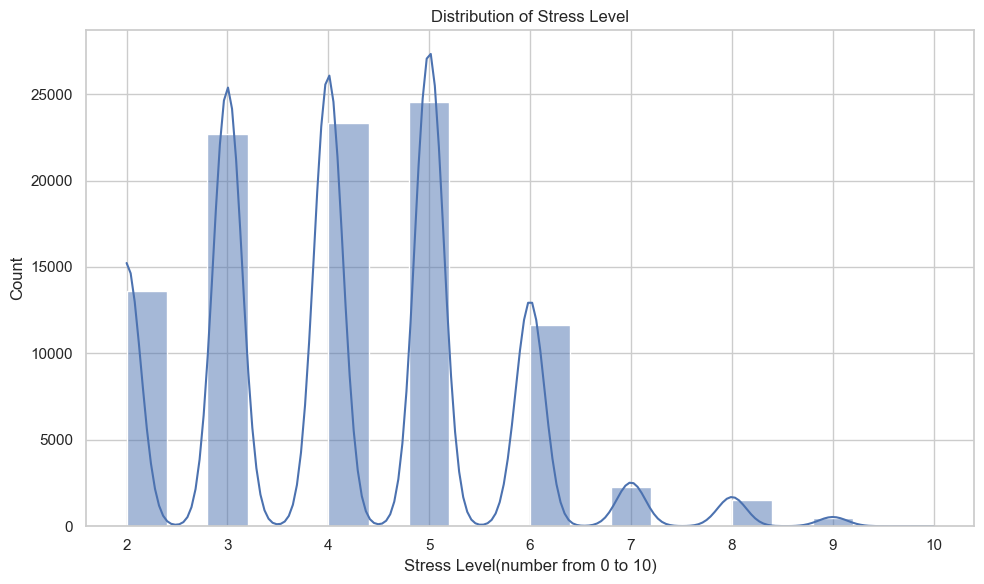

In [25]:
sns.histplot(
  data=df, # данные
  x="Stress_Level", # столбец
  bins=20, # кол-во "столбцов" в гистограмме
  kde=True # сглаженные линии
)

plt.title("Distribution of Stress Level")
plt.xlabel("Stress Level(number from 0 to 10)")
plt.ylabel("Count")

The distribution of stress level is discrete, reflecting the use of an ordinal scale. Most observations are concentrated in the range between 3 and 5, while values of 2 and 6 occur less frequently. Higher stress levels (from 7 to 10) are rare and form the upper tail of the distribution.

Overall, the distribution is centered around mid-range values, with a noticeable decline in frequency toward the higher end of the scale.

Text(0, 0.5, 'Sleep Duration')

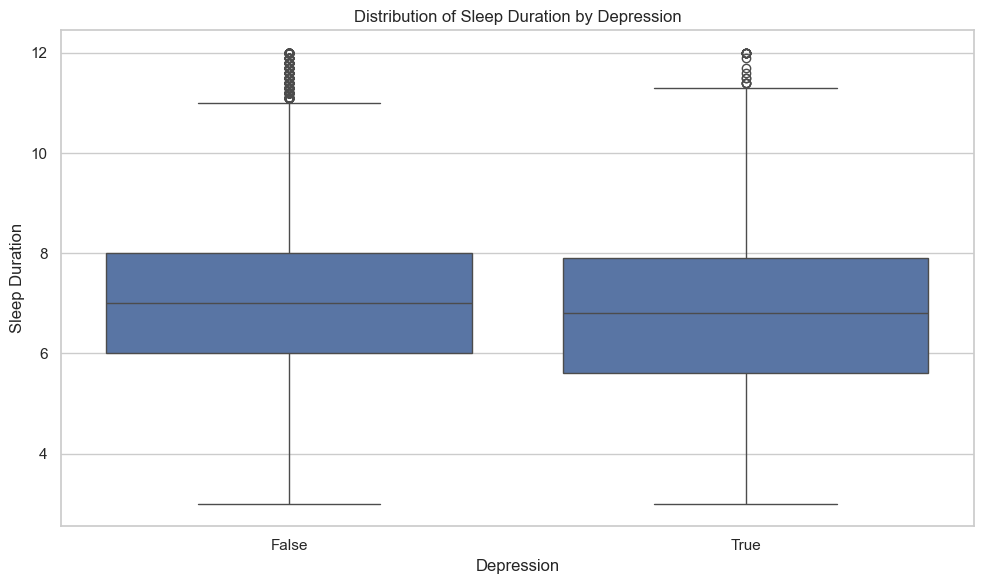

In [ ]:
# -----------------------
# - Bivariate analysis -
# -----------------------

# Ploting boxplot graphic
sns.boxplot(
  data=df,
  x="Depression",
  y="Sleep_Duration"
)

plt.title("Distribution of Sleep Duration by Depression")
plt.xlabel("Depression")
plt.ylabel("Sleep Duration")

### Sleep Duration by Depression

The distribution of sleep duration differs slightly between students with and without depression. The median sleep duration for students classified as depressed is marginally lower compared to those without depression.

The interquartile range for the depressed group appears slightly wider, indicating greater variability in typical sleep durations. Outliers are present in both groups at higher sleep values, suggesting that extreme sleep durations occur regardless of depression status.

Text(0, 0.5, 'Study Hours')

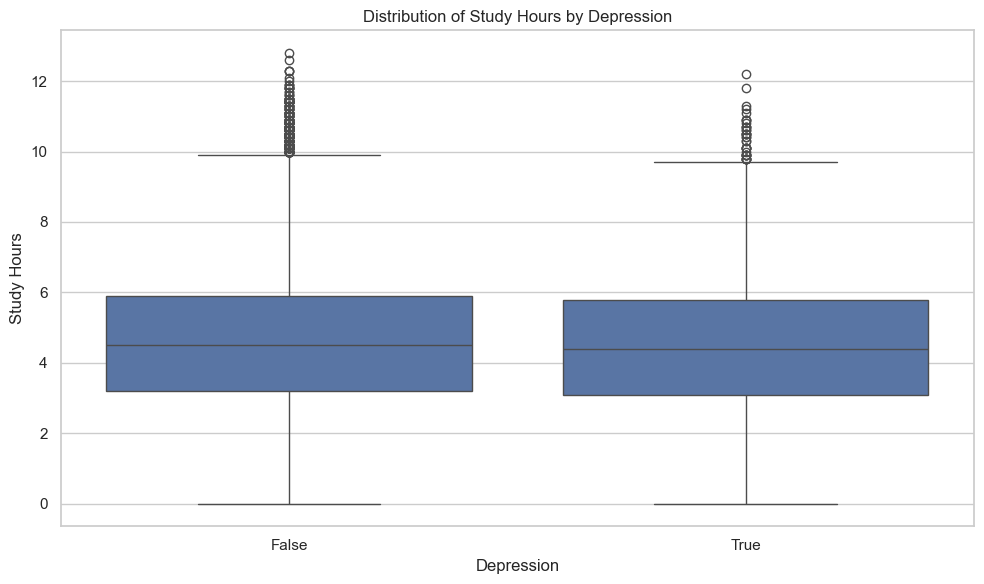

In [28]:
sns.boxplot(
  data=df,
  x="Depression",
  y="Study_Hours"
)

plt.title("Distribution of Study Hours by Depression")
plt.xlabel("Depression")
plt.ylabel("Study Hours")

### Study Hours by Depression

The distributions of study hours for students with and without depression appear highly similar. The median study time is nearly the same in both groups, with only a marginally lower value observed for students classified as depressed.

The interquartile ranges are comparable in size and shape, indicating similar variability in typical study durations across groups. The whiskers are largely symmetric, and outliers occur at similar levels in both groups, although slightly more high-value outliers are observed among students without depression.

Overall, the distributional patterns suggest minimal differences in study hours between the two groups.

Text(0, 0.5, 'Social Media Hours')

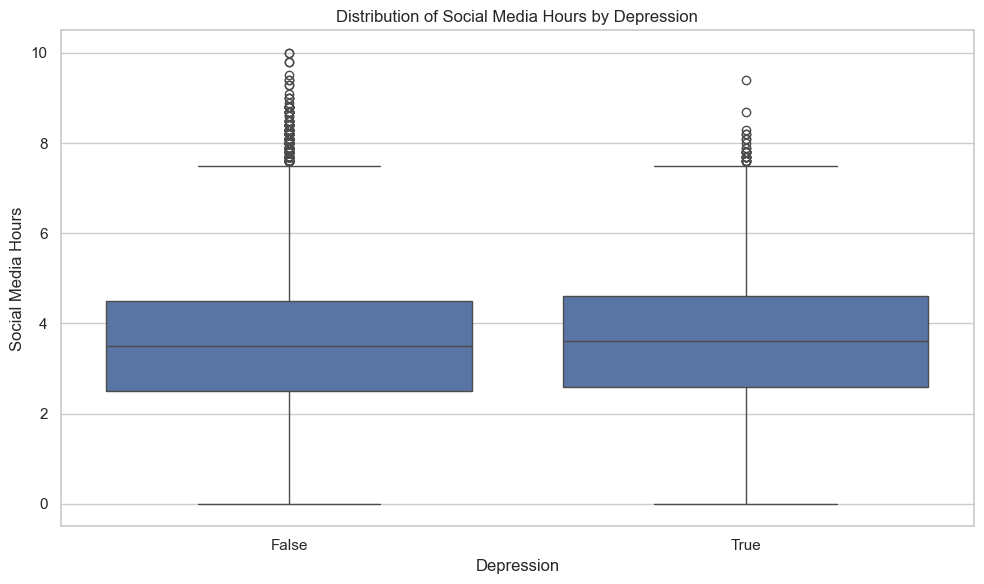

In [29]:
sns.boxplot(
  data=df,
  x="Depression",
  y="Social_Media_Hours"
)

plt.title("Distribution of Social Media Hours by Depression")
plt.xlabel("Depression")
plt.ylabel("Social Media Hours")

### Social Media Hours by Depression

The distributions of social media usage are highly similar for students with and without depression. The median number of social media hours is nearly the same across both groups, with only a marginal difference observed.

The interquartile ranges are comparable in size, indicating similar variability in typical social media usage. Whiskers are largely symmetric, while outliers are present in both groups at higher values. The concentration of high-value outliers highlights the presence of a right-tailed distribution, suggesting that a subset of students spends substantially more time on social media compared to the majority.

Overall, the distributional patterns show minimal differences between the two groups.

Text(0, 0.5, 'Physical Activity')

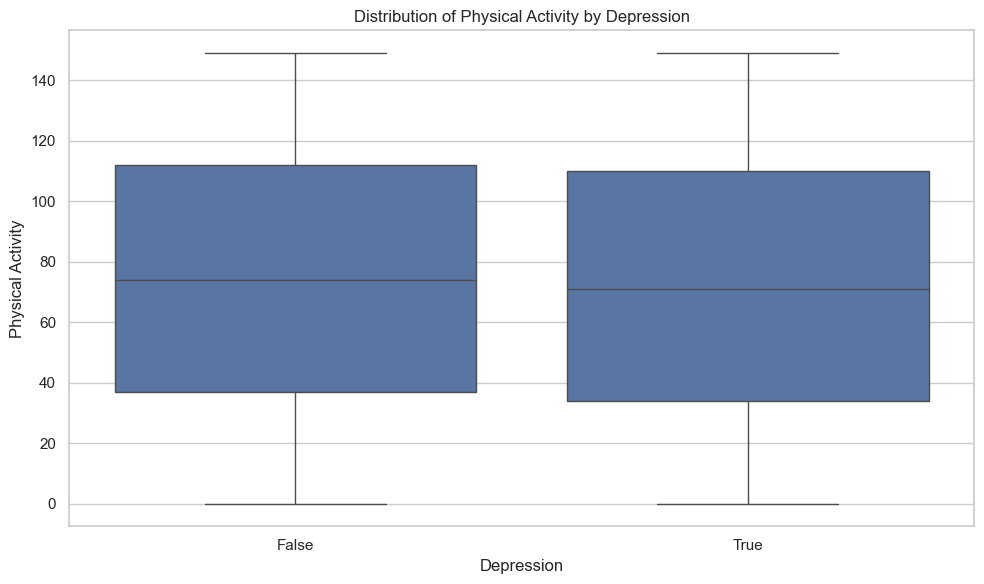

In [30]:
sns.boxplot(
  data=df,
  x="Depression",
  y="Physical_Activity"
)

plt.title("Distribution of Physical Activity by Depression")
plt.xlabel("Depression")
plt.ylabel("Physical Activity")

### Physical Activity by Depression

The distributions of physical activity levels are highly similar for students with and without depression. The median values nearly coincide, with only a marginally lower median observed for students classified as depressed.

The interquartile ranges are comparable in width and shape, indicating similar variability in physical activity across both groups. Whiskers extend symmetrically to the minimum and maximum values, and no outliers are observed in either group.

Overall, the distributions show no noticeable differences in central tendency or tail behavior between students with and without depression.

Text(0, 0.5, 'Stress Level')

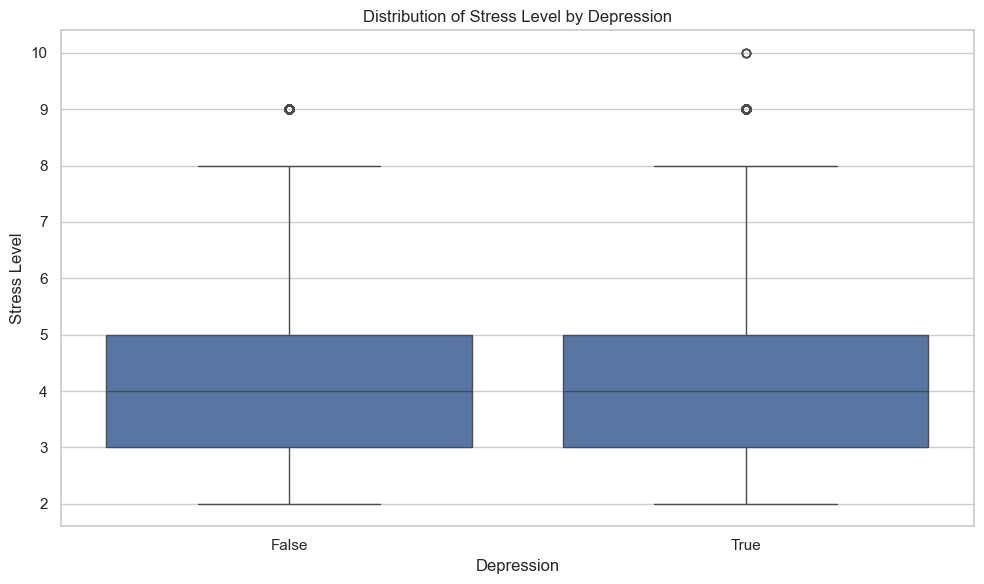

In [31]:
sns.boxplot(
  data=df,
  x="Depression",
  y="Stress_Level"
)

plt.title("Distribution of Stress Level by Depression")
plt.xlabel("Depression")
plt.ylabel("Stress Level")

### Stress Level by Depression

The distributions of stress levels are highly similar for students with and without depression. Median stress levels coincide across both groups and are centered around mid-range values.

The interquartile ranges are comparable in size and shape, indicating similar variability in stress levels between the two groups. Whiskers extend symmetrically toward higher values, while a small number of high-level observations appear as outliers due to the discrete and bounded nature of the stress scale.

Overall, no notable differences in central tendency or distributional shape are observed between students with and without depression.

### Summary of Bivariate Analysis

Across all examined features, the distributions for students with and without depression exhibit highly similar patterns. Median values are closely aligned, and the interquartile ranges show comparable variability across groups for all variables.

Outliers, where present, appear in both groups and at similar levels, indicating that extreme values are not specific to a single group. Overall, none of the analyzed features demonstrates a pronounced distributional shift associated with depression status.

These observations suggest that, at the level of exploratory analysis, the examined lifestyle and behavioral factors display broadly similar distributional characteristics across both groups.

Text(0, 0.5, 'Stress Level')

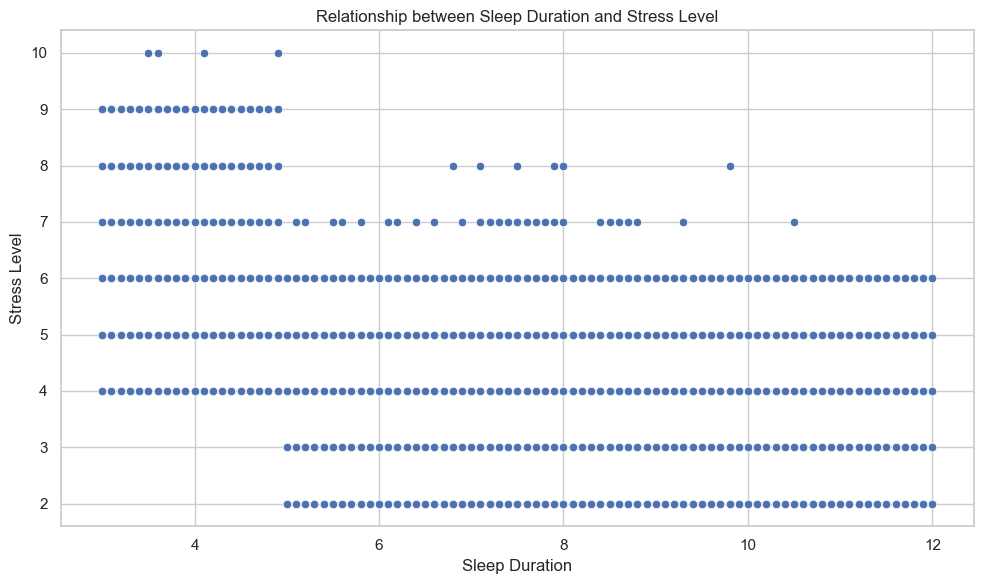

In [34]:
# --------------------
# - Scatterplot and pairplot analysis -
# --------------------

# Ploting graphics
sns.scatterplot(
  data=df,
  x="Sleep_Duration",
  y="Stress_Level",
)

plt.title("Relationship between Sleep Duration and Stress Level")
plt.xlabel("Sleep Duration")
plt.ylabel("Stress Level")

Text(0, 0.5, 'Stress Level')

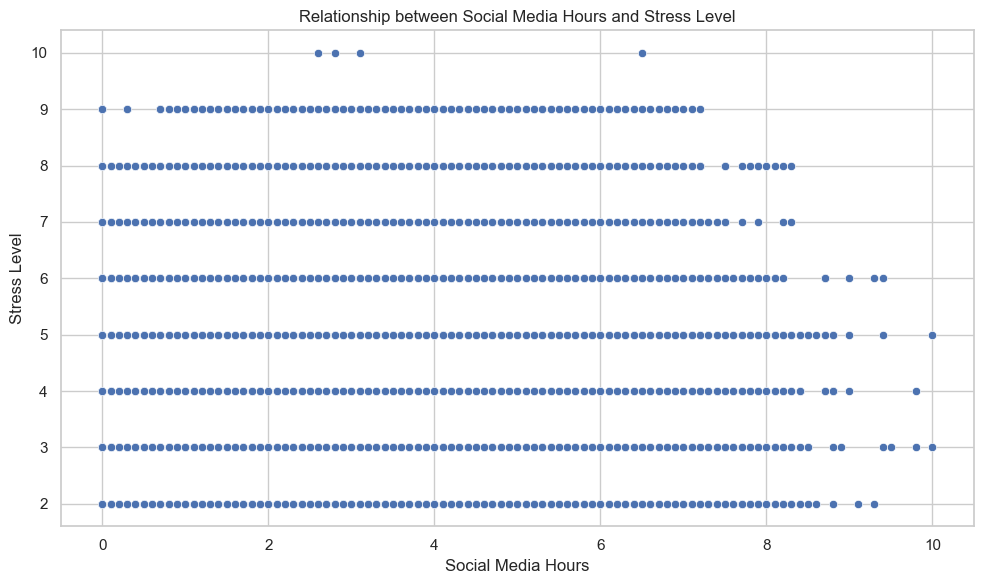

In [35]:
sns.scatterplot(
  data=df,
  x="Social_Media_Hours",
  y="Stress_Level",
)

plt.title("Relationship between Social Media Hours and Stress Level")
plt.xlabel("Social Media Hours")
plt.ylabel("Stress Level")

Text(0, 0.5, 'Stress Level')

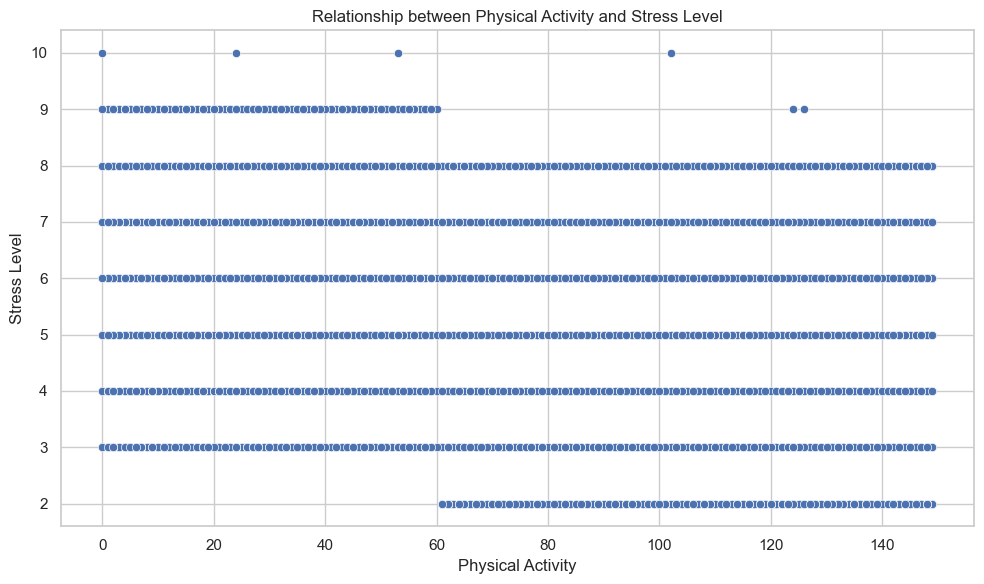

In [42]:
sns.scatterplot(
  data=df,
  x="Physical_Activity",
  y="Stress_Level"
)

plt.title("Relationship between Physical Activity and Stress Level")
plt.xlabel("Physical Activity")
plt.ylabel("Stress Level")

### Pairwise Relationships between Behavioral Factors and Stress Level

Scatter plot analysis of sleep duration, social media usage, and physical activity in relation to stress level does not reveal any clear linear or monotonic relationships. For all examined variables, stress levels span a wide range across the full spectrum of values, indicating substantial variability at any given level of the behavioral factors.

The absence of visible directional trends or clustering suggests that no strong pairwise associations are evident at the exploratory level. Overall, stress levels appear broadly distributed regardless of sleep duration, social media engagement, or physical activity.

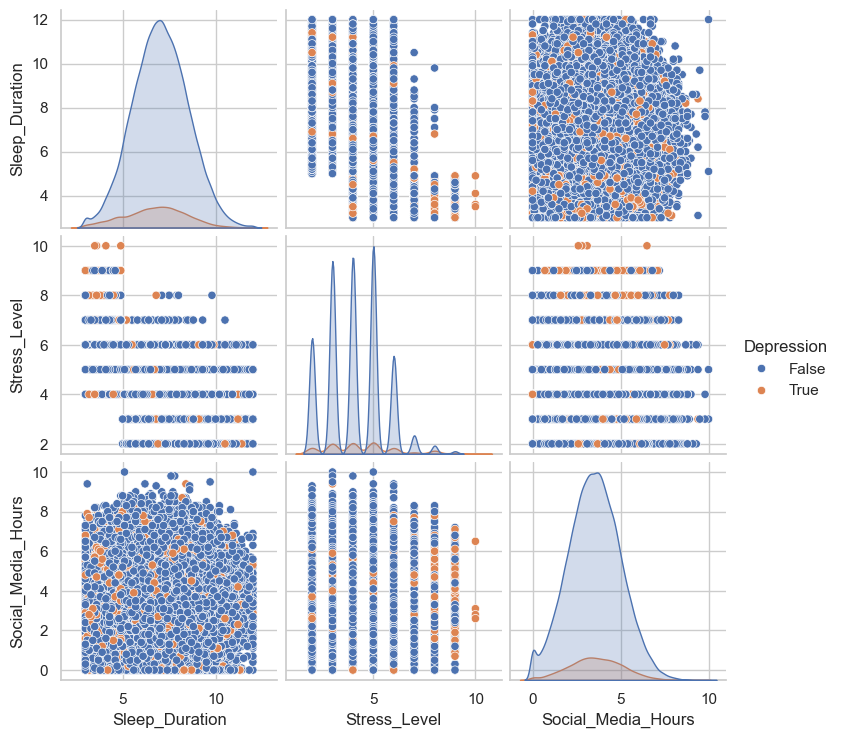

In [43]:
sns.pairplot(
  data=df,
  vars=["Sleep_Duration", "Stress_Level", "Social_Media_Hours"],
  hue="Depression",
  diag_kind="kde",
)

## EDA Conclusions / Key Takeaways

This exploratory data analysis examined the distributions and relationships of key demographic, behavioral, and lifestyle factors in relation to students’ depression status.

Univariate analysis showed that most numerical features exhibit well-behaved and realistic distributions, with values concentrated within plausible ranges and no missing data detected. Stress level and physical activity variables reflect the discrete and bounded nature of their underlying scales, while sleep duration, study hours, and social media usage display smooth, unimodal distributions.

Bivariate analysis using boxplots revealed that, across all examined features, the distributions for students with and without depression are highly similar. Median values are closely aligned, interquartile ranges are comparable, and no substantial differences in variability or tail behavior are observed between the two groups. Outliers, where present, occur in both groups and do not appear to be group-specific.

Pairwise scatter plot analysis further supports these findings. No clear linear or monotonic relationships are visually evident between stress level and behavioral factors such as sleep duration, social media usage, or physical activity. Across all examined relationships, stress levels remain widely distributed regardless of the values of other variables.

Overall, the exploratory analysis suggests that, at the level of distributional and visual inspection, the examined lifestyle and behavioral factors do not exhibit strong or distinct patterns associated with depression status. These results indicate that any potential relationships, if present, are likely subtle and not immediately apparent through exploratory visualization alone.